# 文本分类思路
- 整个代码包括：数据解析加载、模型构建、损失函数构建、优化器构建、迭代训练、模型评估可视化、模型持久化等相关逻辑；
- 数据解析加载：
  * 原始数据格式信息分析：原始数据为磁盘中的文本数据，使用csv格式存储，主要有两个信息：文本数据 -> str  文本对应标签类别名称 -> str;
  * 定义好文本分词/划分Token的方式：词(Word)、字符(Char)、子词(Sub-Word)
    - 第一版中直接采用基于jieba进行原始的分词
  * 构建词典映射mapping以及输出到磁盘
  * 构建标签映射mapping以及输出到磁盘
  * 构建分词器：简化分词、token2id的转换过程 --> 面向对象编程
  * 构建数据加载器DataSet：自定义Dataset，利用构建好的分词器对文本数据进行分词以及token转id的操作；
  * 构建批次数据加载器DataLoader：自定义批次数据合并的方法；
- 模型构建：
  - 模型输入：
      * 批次样本token id列表，shape形状为：\[bs,t], 内部取值就是每个token对应的id；
      * 批次样本token填充信息，shape形状为: \[bs,t], 1表示当前token id为实际值，0表示当前位置的token id是填充值；
      * eg:
        + token_ids: ```torch.tensor([[12,25,36,12], [78,56,45,0]])```  表示两个样本，每个样本有4个输入token；
        + token_masks: ```torch.tensor([[1,1,1,1], [1,1,1,0]])``` 表示两个样本，其中第一个样本的所有token全部为实际值，第二个样本有一个填充token；
  - 模型输出：
      * 模型预测各个样本属于各个类别的置信度，shape形状为:\[bs,num_class]；
      * eg:
        + score: ```torch.tensor([ [0.25,-2.5,3.15], [10.25,-0.21,-3.5] ])``` 表示两个样本，每个样本属于3个类别的置信度值；
  - 模型参数恢复：
    * 如果当前模型有给定持久化参数，那么直接恢复对应的模型参数；
- 损失函数构建：
  - 属于分类任务可以直接采用交叉熵损失函数: ```nn.CrossEntropyLoss```
- 优化器构建：
  - 可直接采用SGD优化器: ```optim.SGD(net.parameters(), lr=0.001)```
  - PS: 也可以针对不同参数使用不同的优化器，以及采用动态学习率的更新方式等；
- 迭代训练：
  - 普通代码逻辑，直接循环处理dataloader获取批次数据，然后分别调用前向计算损失以及反向更新模型参数；
- 模型评估可视化：
  - 普通代码逻辑：直接循环处理dataloader获取批次数据，获取数据对应的预测结果，比较预测结果和实际结果得到评估指标；
  - 属于分类任务可以直接采用分类评估指标：准确率、F1值等；
- 模型持久化：
  - 每执行完一个epoch，持久化一个last.pkl的模型文件；
  - 基于模型评估效果值(准确率或者F1等)，当模型评估效果提升的时候，持久化一个best.pkl模型文件；
  - 持久化的pkl文件中主要包含：模型参数、优化器参数、epoch、评估效果、时间等信息；

In [1]:
import json  # 导入json模块，用于读写JSON格式的数据文件
import os  # 导入os模块，用于操作系统级别的文件路径和目录处理
from dataclasses import dataclass  # 导入dataclass，用于以更简洁的方式定义数据结构类
from datetime import datetime  # 导入datetime，用于获取和处理时间戳
from typing import List, Optional, Dict  # 导入类型注解模块，用于在函数定义中注明参数和返回值的类型

import matplotlib.pyplot as plt  # 导入matplotlib的pyplot模块，用于绘制各类图表（如直方图）
import numpy as np  # 导入numpy，用于进行高效的数值计算和数组操作
import pandas as pd  # 导入pandas模块，用于加载、操作和分析结构化表格数据（如CSV）
import torch  # 导入深度学习核心框架 PyTorch
import torch.nn as nn  # 导入PyTorch的神经网络模块（包含各类网络层、损失函数等）
import torch.optim as optim  # 导入PyTorch的优化器模块（如SGD、Adam等）
from sklearn import metrics  # 导入scikit-learn的评估模块，用于计算准确率、F1值等评估指标
from torch.utils.data import DataLoader, Dataset  # 导入PyTorch的数据加载工具，用于批次读取数据
from tqdm import tqdm  # 导入tqdm，用于在循环中显示进度条

# pip install tensorboard
from torch.utils.tensorboard import SummaryWriter

import jieba  # 导入jieba模块，这是一个常用的中文分词库

C:\MySoftware\Anaconda3\envs\cv1\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\MySoftware\Anaconda3\envs\cv1\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
C:\MySoftware\Anaconda3\envs\cv1\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


### 数据集拆分

In [2]:
# 使用pandas读取位于指定路径的CSV格式文本数据
# sep="\t" 指定列之间的分隔符为制表符(Tab)
# header=None 表示源文件第一行不是表头
# names=['text', 'label'] 手动为读取的数据指定列名：第一列为文本内容，第二列为对应的分类标签
df = pd.read_csv(
    r"./datas/intention/train.csv",
    sep="\t", header=None, names=['text', 'label']
)
df.head(2)  # 打印出DataFrame的前两行数据，用于检查数据是否正常被加载

,text,label
0,还有双鸭山到淮阴的汽车票吗13号的,Travel-Query
1,从这里怎么回家,Travel-Query


In [3]:
from sklearn.model_selection import train_test_split  # 从sklearn库导入数据集切分函数

# 将完整的数据集 df 划分为训练集 df0 和验证集 df1
# test_size=0.1 表示验证集占总数据的10%，训练集占90%
# random_state=2 设置随机种子，保证每次运行代码时切分的结果是固定的，方便复现
df0, df1 = train_test_split(df, test_size=0.1, random_state=2)
print(df0.shape, df1.shape)  # 打印切分后训练集和验证集的形状（即 行数 x 列数）

# 将划分好的训练集 df0 保存为新的CSV文件
# sep="\t" 同样使用制表符分隔，index=None 表示不将行号写入文件，header=None 表示不写入表头列名
df0.to_csv(r"./datas/intention/train0.csv", sep="\t", index=None, header=None)
# 将划分好的验证集 df1 也保存为新的CSV文件，参数与上述一致
df1.to_csv(r"./datas/intention/val0.csv", sep="\t", index=None, header=None)

(10890, 2) (1210, 2)


### 定义通用方法

In [4]:
def load_json(json_file):
    # 以只读模式("r")和 UTF-8 编码打开指定的 json 文件
    with open(json_file, "r", encoding="utf-8") as reader:
        # 读取并解析该 JSON 文件的内容，将其转化为 Python 的字典或列表并返回
        return json.load(reader)


def save_json(json_file, json_obj):
    # 根据传入的文件路径，提取出其所在的目录。如果该目录不存在，则自动创建它 (exist_ok=True)
    os.makedirs(os.path.dirname(json_file), exist_ok=True)
    # 以写入模式("w")和 UTF-8 编码打开文件
    with open(json_file, "w", encoding="utf-8") as writer:
        # 将传入的 Python 对象 json_obj 格式化为 JSON 字符串并写入文件
        # indent=2 设置两格缩进增加可读性，ensure_ascii=False 确保中文字符能原样保存而不是变成Unicode码
        json.dump(json_obj, writer, indent=2, ensure_ascii=False)

### 定义文本分词的方法

In [5]:
def split_text_to_tokens_with_jieba(text: str) -> List[str]:
    # 使用 jieba 的 lcut 方法将输入的字符串进行精确模式的分词，并返回一个词语列表
    return jieba.lcut(text)

In [6]:
def split_text_to_tokens_with_char(text: str) -> List[str]:
    # 将输入的字符串直接转换为列表，相当于按单个字符（字）进行拆分
    return list(text)

In [7]:
def split_text_to_tokens(text: str) -> List[str]:
    """
    将给定文本转换为token列表（综合分词入口）
    :param text: 文本字符串, eg: 从这里怎么回家
    :return: token组成的list列表, eg: ["从", "这里", "怎么", "回家"]
    """
    # 此处调用了基于 jieba 的词级别分词函数（按字的方案被注释掉了）
    _tokens = split_text_to_tokens_with_jieba(text)
    # _tokens = split_text_to_tokens_with_char(text) 

    # 采用列表推导式，将切分后的所有 token 统一转换为小写字母（主要针对包含英文的文本）
    _tokens = [_token.lower() for _token in _tokens]
    return _tokens

In [8]:
# 测试刚才定义的分词函数，检查中英文混合时的表现
split_text_to_tokens("从这里怎么回家My")

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\lzx84\AppData\Local\Temp\jieba.cache
Loading model cost 0.436 seconds.
Prefix dict has been built successfully.


['从', '这里', '怎么', '回家', 'my']

### 构建Token和label的映射mapping

In [9]:
df = pd.read_csv(r"./datas/intention/train.csv", sep="\t", header=None, names=['text', 'label'])
df.head(3)

,text,label
0,还有双鸭山到淮阴的汽车票吗13号的,Travel-Query
1,从这里怎么回家,Travel-Query
2,随便播放一首专辑阁楼里的佛里的歌,Music-Play


In [10]:
token2cnt = {}  # 初始化一个空字典，用于存储每个 token 及其在所有数据集中出现的总次数
label2cnt = {}  # 初始化一个空字典，用于存储每个 标签类别 及其对应的样本数量
text_lens = []  # 初始化一个列表，用于记录每一条文本分词后的 token 数量（长度）

# 使用 iterrows() 逐行遍历数据集
for items in df.iterrows():
    # 提取当前行的文本，并使用 strip() 去除首尾的多余空格和换行符
    text = items[1]['text'].strip()
    # 提取当前行的标签，同样使用 strip() 净化字符
    label = items[1]['label'].strip()

    # 将当前文本传给分词函数，得到词列表
    tokens = split_text_to_tokens(text)

    # 遍历切分出来的每一个词
    for token in tokens:
        # dict.get(token, 0) 表示如果字典中没有该词则默认值为0，然后+1；实现词频累加
        token2cnt[token] = token2cnt.get(token, 0) + 1

    # 对当前样本的标签类别进行频次累加
    label2cnt[label] = label2cnt.get(label, 0) + 1
    # 将当前这条文本包含的词汇数量添加到列表中，以便后续分析文本长度分布
    text_lens.append(len(tokens))

print(f"总Token数量为:{len(token2cnt)}")  # 输出不重复词汇（词汇表）的总量
print(f"总标签数量为:{len(label2cnt)}")  # 输出分类任务中的总类别数
print(label2cnt)  # 打印所有标签及其对应的样本数，检查是否存在数据不平衡

总Token数量为:11136
总标签数量为:12
{'Travel-Query': 1220, 'Music-Play': 1304, 'FilmTele-Play': 1355, 'Video-Play': 1334, 'Radio-Listen': 1285, 'HomeAppliance-Control': 1215, 'Weather-Query': 1229, 'Alarm-Update': 1264, 'Calendar-Query': 1214, 'TVProgram-Play': 240, 'Audio-Play': 226, 'Other': 214}


### 词频统计可视化

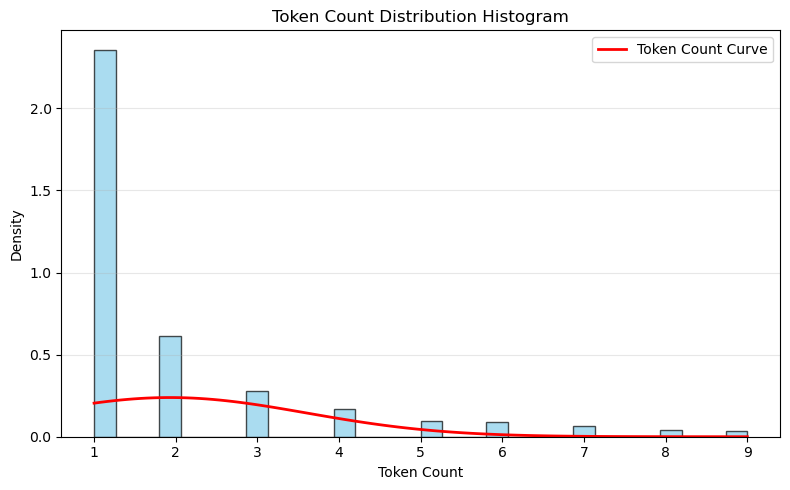

In [11]:
#tmp_token_cnt = list([v for _, v in token2cnt.items()])
# 筛选出字典中出现频次小于10次的词（过滤掉高频词），将它们的频次提取成一个列表
tmp_token_cnt = list([v for _, v in token2cnt.items() if v < 10])

plt.figure(figsize=(8, 5))  # 创建一个宽8英寸、高5英寸的画板对象
# 调用直方图绘制函数 hist()
n, bins, patches = plt.hist(
    tmp_token_cnt,  # 传入的数据（即小于10次的各类低频词频次列表）
    bins=30,  # 分箱数量设为30，即将X轴数据分为30个柱子
    density=True,  # 开启密度归一化，使得直方图所占的总面积等于1（从而可以绘制概率密度曲线）
    alpha=0.7,  # 设置柱子的颜色透明度为0.7
    color='skyblue',  # 柱子填充颜色设为天蓝色
    edgecolor='black'  # 柱子边框颜色设为黑色
)

# 添加图表的辅助信息
plt.title('Token Count Distribution Histogram')  # 给图表添加总标题
plt.xlabel('Token Count')  # 标注X轴含义（词频数目）
plt.ylabel('Density')  # 标注Y轴含义（密度大小）

# 添加一条理论的正态分布曲线作为辅助参考线
# 利用numpy计算出这份数据的平均值(mu)和标准差(sigma)
mu, sigma = np.mean(tmp_token_cnt), np.std(tmp_token_cnt)
# 在最小分箱和最大分箱范围内均匀生成100个采样点，作为X轴数据
x = np.linspace(min(bins), max(bins), 100)
# 根据正态分布的概率密度函数公式计算出对应的Y轴理论值，并画出一条红色实线('r-')，线宽lw=2
plt.plot(x, 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(- (x - mu) ** 2 / (2 * sigma ** 2)), 'r-', lw=2,
         label='Token Count Curve')

plt.legend()  # 显示图例，使得图表上出现 'Token Count Curve' 的标记
plt.grid(axis='y', alpha=0.3)  # 添加Y轴方向的背景横向网格线，透明度设为0.3，方便读数
plt.tight_layout()  # 自动调整子图参数，防止标签、标题等元素溢出或重叠
plt.show()  # 渲染并弹出最终画好的图表

In [12]:
# 过滤掉词频小于或等于2的词，并将保留下来的词及其频次转为列表（这里仅为查看数据，未实际接收返回值）
list([(k, v) for k, v in token2cnt.items() if v > 1000])

[('的', 7915),
 ('吗', 1560),
 ('播放', 1729),
 ('给', 1443),
 ('一下', 1756),
 ('我', 4755),
 ('是', 1718),
 ('帮', 1396)]

In [13]:
print(len(token2cnt))  # 打印原始总词汇量
print(len(list([(k, v) for k, v in token2cnt.items() if v == 1])))  # 打印只出现过1次的“低频词”数量

11136
6308


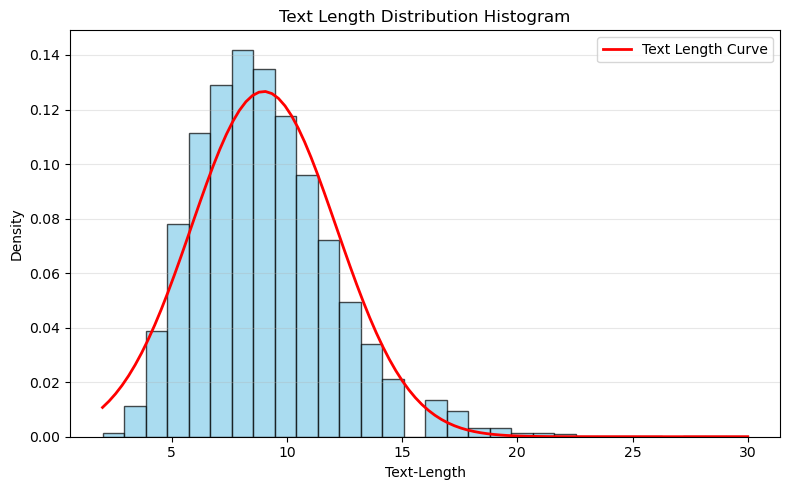

In [14]:
# 可视化看看文本 长度的分布图
plt.figure(figsize=(8, 5))  # 设置图像大小
n, bins, patches = plt.hist(
    text_lens,  # 数据
    bins=30,  # 分箱数量
    density=True,  # 密度归一化
    alpha=0.7,  # 透明度
    color='skyblue',  # 颜色
    edgecolor='black'  # 边框颜色
)

# 添加标题和标签
plt.title('Text Length Distribution Histogram')
plt.xlabel('Text-Length')
plt.ylabel('Density')

# 添加正态分布曲线作为参考
mu, sigma = np.mean(text_lens), np.std(text_lens)
x = np.linspace(min(bins), max(bins), 100)
plt.plot(x, 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(- (x - mu) ** 2 / (2 * sigma ** 2)), 'r-', lw=2,
         label='Text Length Curve')

plt.legend()  # 显示图例
plt.grid(axis='y', alpha=0.3)  # 添加网格线
plt.tight_layout()  # 自动调整布局
plt.show()

In [15]:
# 基于单词的数量构建词典字典 (Token to ID)
token2ids = {
    "<PAD>": 0,  # 预留给 Padding (填充) 的特殊标记，ID设为0
    "<UNK>": 1  # 预留给 Unknown (未知词/生僻词) 的特殊标记，ID设为1
}

# 遍历词频统计字典
for token, cnt in token2cnt.items():
    if cnt < 3:
        continue  # 如果这个词在整个数据集中出现不到3次，直接过滤掉（当作<UNK>处理）
    # 为保留下来的词分配一个新的ID，len(token2ids)刚好能保证ID是自增且不重复的整数
    token2ids[token] = len(token2ids)

# 将构建好的词汇-ID映射表保存到本地磁盘
save_json("./output/intention/token2ids.json", token2ids)

In [16]:
# 构建标签字典 (Label to ID)
label2ids = {}
for label, cnt in label2cnt.items():
    # 为每一个分类标签分配一个整数ID
    label2ids[label] = len(label2ids)

# 将标签映射表也保存到本地
save_json("./output/intention/label2ids.json", label2ids)

### 分词器

In [17]:
@dataclass
class TokenizerOutput:
    """定义分词器输出的数据结构"""
    text: str  # 原始文本
    tokens: List[str]  # 切分后的 token 列表
    token_ids: List[int]  # 转换后的整数 ID 列表
    label: Optional[str] = None  # 原始标签（可选，推理时可能没有）
    label_id: Optional[int] = 0  # 标签对应的 ID

In [18]:
class Tokenizer:
    def __init__(self, token2ids: Dict[str, int], label2ids: Dict[str, int], unk_token='<UNK>', pad_token='<PAD>'):
        super().__init__()
        self.token2ids = token2ids  # 传入词典映射
        # 获取特殊标记的ID（找不到对应词时就用 unk_token_id）
        self.unk_token_id = self.token2ids[unk_token]
        self.pad_token_id = self.token2ids[pad_token]
        self.label2ids = label2ids  # 传入标签映射

    def __call__(self, text: str, label: Optional[str] = None) -> TokenizerOutput:
        """使类的实例可以像函数一样被调用: tokenizer(text, label)"""
        # 1. 分词：调用之前定义的通用分词函数
        tokens = split_text_to_tokens(text)

        # 2. Token转ID：遍历切分好的词，去字典里查ID。查不到(get不到)就返回 unk_token_id
        token_ids = [self.token2ids.get(token, self.unk_token_id) for token in tokens]

        # 3. 标签转换：如果传入了标签，也去字典里查出对应的ID
        label_id = None
        if label is not None:
            label_id = self.label2ids[label]

        # 返回按照 TokenizerOutput 结构组装好的数据
        return TokenizerOutput(text, tokens, token_ids, label, label_id)

In [19]:
# 加载保存好的字典，实例化并测试 Tokenizer
token2ids = load_json(r"./output/intention/token2ids.json")
label2ids = load_json(r"./output/intention/label2ids.json")
tokenizer = Tokenizer(token2ids, label2ids)
tokenizer("怎么从这里回家", "Travel-Query")  # 测试分词器运行是否正常

TokenizerOutput(text='怎么从这里回家', tokens=['怎么', '从', '这里', '回家'], token_ids=[12, 10, 11, 13], label='Travel-Query', label_id=0)

### Dataset定义及创建

In [20]:
class TextClassifyDataset(Dataset):
    """自定义 PyTorch 数据集"""

    def __init__(self, texts: List[str], labels: List[str], tokenizer: Tokenizer):
        super().__init__()
        self.texts = texts  # 所有的文本数据列表
        self.labels = labels  # 对应的所有标签列表
        self.tokenizer = tokenizer  # 实例化的分词器对象

    def __getitem__(self, index):
        """根据索引获取一条数据，PyTorch DataLoader 底层会疯狂调用这个方法"""
        # 1. 取出对应的字符串
        text = self.texts[index]
        label = self.labels[index]

        # 2. 调用分词器，完成 字符串 -> ID 的转换
        tokenizer_output = self.tokenizer(text=text, label=label)

        # 3. 返回供模型使用的字典格式（注意这里将列表转化为了PyTorch的Tensor张量）
        return {
            'text': tokenizer_output.text,
            'tokens': tokenizer_output.tokens,
            'token_ids': torch.tensor(tokenizer_output.token_ids, dtype=torch.int64),
            # 创建掩码(Mask)：因为后面不同长度的句子会被填充到一样长，真实存在的词标记为1
            'token_masks': torch.ones(len(tokenizer_output.token_ids), dtype=torch.float32),
            'label': tokenizer_output.label,
            'label_id': torch.tensor(tokenizer_output.label_id, dtype=torch.int64)
        }

    def __len__(self):
        """返回数据集的总样本数"""
        return len(self.texts)

In [21]:
df = pd.read_csv(r"./datas/intention/train.csv", sep="\t", header=None, names=['text', 'label'])
ds = TextClassifyDataset(texts=df.text.values, labels=df.label.values, tokenizer=tokenizer)

In [22]:
ds[10]

{'text': '单曲循环一首催眠的歌吧',
 'tokens': ['单曲', '循环', '一首', '催眠', '的', '歌', '吧'],
 'token_ids': tensor([60, 61, 16,  1,  5, 19, 62]),
 'token_masks': tensor([1., 1., 1., 1., 1., 1., 1.]),
 'label': 'Music-Play',
 'label_id': tensor(1)}

In [23]:
ds[11]

{'text': '你能播放一下曹盾导演的古装悬疑剧呢',
 'tokens': ['你', '能', '播放', '一下', '曹盾', '导演', '的', '古装', '悬疑剧', '呢'],
 'token_ids': tensor([63, 64, 15, 22,  1, 65,  5, 36, 66, 46]),
 'token_masks': tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'label': 'FilmTele-Play',
 'label_id': tensor(2)}

### 构建DataLoader

In [24]:
# 编写自定义的 collate_fn (收集函数)
# 因为一个Batch里每句话长度不一样，PyTorch无法把它们直接拼成一个矩阵，需要动态Padding(填充)
def build_collect_fn(pad_token_id):
    def _collect_fn(_batch):
        # 找出当前这批数据（Batch）中最长的那句话的长度
        max_len = max([len(_item['token_ids']) for _item in _batch])

        # 初始化用于收集这批数据的空列表
        _batch_text, _batch_tokens, _batch_token_ids, _batch_token_masks, _batch_label, _batch_label_id = [], [], [], [], [], []

        for _item in _batch:
            # 基础信息直接放入列表
            _batch_text.append(_item['text'])
            _batch_tokens.append(_item['tokens'])
            _batch_label.append(_item['label'])
            _batch_label_id.append(_item['label_id'])

            _token_ids = _item['token_ids']
            _token_masks = _item['token_masks']

            # 核心：如果当前这句话比最长的那句话短，就需要补齐
            if len(_token_ids) < max_len:
                _pad_size = max_len - len(_token_ids)  # 计算需要补几个 PAD

                # 拼接真实的 ID 和 补齐的 PAD ID (值为pad_token_id)
                _token_ids = torch.cat([
                    _token_ids,
                    torch.ones(size=(_pad_size,), dtype=_token_ids.dtype, device=_token_ids.device) * pad_token_id
                ], dim=0)

                # 对应的 Mask 也要补齐，补齐的部分填 0，表示这里是假的（填充词）
                _token_masks = torch.cat([
                    _token_masks,
                    torch.zeros(size=(_pad_size,), dtype=_token_masks.dtype, device=_token_masks.device)
                ], dim=0)

            _batch_token_ids.append(_token_ids)
            _batch_token_masks.append(_token_masks)

        # 返回组合好的一个 Batch 数据，全部 stack 成矩阵(Tensor)
        return {
            'text': _batch_text,
            'tokens': _batch_tokens,
            'label': _batch_label,
            'label_id': torch.stack(_batch_label_id, dim=0),
            'token_ids': torch.stack(_batch_token_ids, dim=0),
            'token_masks': torch.stack(_batch_token_masks, dim=0)
        }

    return _collect_fn

In [25]:
# 封装 DataLoader 构建函数
def build_dataloader(ds: TextClassifyDataset, batch_size, shuffle=False):
    return DataLoader(
        dataset=ds,
        batch_size=batch_size,
        shuffle=shuffle,  # 训练集通常需要打乱(True)，验证集不需要(False)
        collate_fn=build_collect_fn(pad_token_id=ds.tokenizer.pad_token_id)  # 传入刚刚写的填充函数
    )

In [26]:
dataloader = build_dataloader(ds, batch_size=2, shuffle=True)

In [27]:
for batch in dataloader:
    print(batch)
    break

{'text': ['查询沧州气温变化规律', '将客厅的空气净化器打开吧'], 'tokens': [['查询', '沧州', '气温', '变化规律'], ['将', '客厅', '的', '空气', '净化器', '打开', '吧']], 'label': ['Weather-Query', 'HomeAppliance-Control'], 'label_id': tensor([6, 5]), 'token_ids': tensor([[  85, 1098,  209,    1,    0,    0,    0],
        [ 308,   98,    5,  325,  326,  105,   62]]), 'token_masks': tensor([[1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1.]])}


### 模型结构创建

In [28]:
class TextClassifyNetwork(nn.Module):
    def __init__(self, vocab_size, num_classes, hidden_size=128):
        super().__init__()
        # Embedding层：词向量查询表，将离散的词ID(整数)映射为连续的稠密向量(浮点数)
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=hidden_size)

        # 特征提取层：使用几层全连接网络(Linear) + 激活函数(ReLU) 对词特征进行非线性变换
        self.token_features = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.ReLU(),
            nn.Linear(hidden_size * 4, hidden_size * 4),
            nn.ReLU(),
            nn.Linear(hidden_size * 4, hidden_size),
            nn.ReLU()
        )

        # 分类头：将最终提取出的文本特征维度，映射到对应的类别数量上进行打分
        self.classify = nn.Linear(hidden_size, num_classes, bias=False)

    def forward(self, token_ids, token_masks):
        """定义前向传播逻辑 (数据在网络中是怎么流动的)"""
        # 1. 查表：输入维度[bs, 序列长度]，输出维度[bs, 序列长度, 隐藏层维度(如128)]
        token_embs = self.embedding_layer(token_ids)

        # 2. 提特征：通过全连接层，维度保持 [bs, T, e]
        token_embs = self.token_features(token_embs)

        # 3. Mean Pooling (平均池化)：将每个词的向量融合成整句话的向量
        # 计算每句话实际有多少个词（过滤掉Padding的影响）
        text_lens = torch.sum(token_masks, dim=1, keepdim=True)  # [bs, 1]

        # 将 Padding 对应位置的词向量强制归零，防止干扰最终结果
        # token_masks[:, :, None] 是为了在最后一维扩充，使其形状能与 token_embs 匹配相乘
        token_embs = token_embs * token_masks[:, :, None]

        # 把每个词的向量累加起来，除以真实的句子长度得到平均向量
        # 加 1e-8 是为了防止出现分母为0的极端情况（数值稳定性）
        text_embs = torch.sum(token_embs, dim=1) / (text_lens + 1e-8)  # 输出形状: [bs, e]

        # 4. 预测打分：输出属于不同分类的得分(Logits)
        score = self.classify(text_embs)  # 输出形状: [bs, num_classes]

        return score

In [29]:
net = TextClassifyNetwork(vocab_size=10000, num_classes=13, hidden_size=128)
print(net)

token_ids = torch.tensor([
    [202, 331, 188, 5, 1, 665, 0, 0, 0, 0, 0, 0, 0, 0],  # 第一个文本
    [24, 597, 1219, 1022, 136, 9, 135, 538, 565, 626, 1, 5, 1138, 117]  # 第二个文本
])
token_masks = torch.tensor([
    [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],  # 第一个文本 实际token数目6个，填充token数目为8个
    # [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],  # 第一个文本 实际token数目6个，填充token数目为8个
    [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]  # 第二个文本 14个token均为实际token
])

r = net(token_ids, token_masks)
print(r)

TextClassifyNetwork(
  (embedding_layer): Embedding(10000, 128)
  (token_features): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
  )
  (classify): Linear(in_features=128, out_features=13, bias=False)
)
tensor([[ 0.0315, -0.0071, -0.0230,  0.0015, -0.0490,  0.0315,  0.0311, -0.0248,
          0.0108, -0.0159, -0.0273, -0.0160, -0.0027],
        [ 0.0338, -0.0074, -0.0165,  0.0062, -0.0438,  0.0234,  0.0186, -0.0244,
          0.0093, -0.0074, -0.0241, -0.0160,  0.0013]], grad_fn=<MmBackward0>)


### 组装整个训练结构

In [30]:
class Trainer(object):
    def __init__(self, train_csv_path, val_csv_path, token2ids_path, label2ids_path, model_output_dir, summary_dir,
                 total_epoch=100, batch_size=8, hidden_size=128, lr=0.01):
        super().__init__()

        self.total_epoch = total_epoch
        self.last_model_path = os.path.join(model_output_dir, "last.pkl")
        os.makedirs(os.path.dirname(self.last_model_path), exist_ok=True)

        # 1. 分词器的构建
        self.token2ids = load_json(token2ids_path)
        self.label2ids = load_json(label2ids_path)
        self.tokenizer = Tokenizer(self.token2ids, self.label2ids)

        # 2. 训练数据构造
        train_df = pd.read_csv(train_csv_path, sep="\t", header=None, names=['text', 'label'])
        train_ds = TextClassifyDataset(
            texts=train_df.text.values,
            labels=train_df.label.values,
            tokenizer=self.tokenizer
        )
        self.train_dataloader = build_dataloader(
            train_ds, batch_size=batch_size, shuffle=True
        )

        # 3. 验证数据的加载
        val_df = pd.read_csv(val_csv_path, sep="\t", header=None, names=['text', 'label'])
        val_ds = TextClassifyDataset(
            texts=val_df.text.values,
            labels=val_df.label.values,
            tokenizer=self.tokenizer
        )
        self.test_dataloader = build_dataloader(
            val_ds, batch_size=batch_size, shuffle=False
        )

        self.net = TextClassifyNetwork(
            vocab_size=len(self.token2ids),
            num_classes=len(self.label2ids),
            hidden_size=hidden_size
        )
        # 损失函数：交叉熵损失，这是分类任务中最常用的损失函数
        self.loss_fn = nn.CrossEntropyLoss()
        # 优化器：随机梯度下降(SGD)，负责根据算出来的损失去更新模型参数
        self.opt = optim.SGD(params=net.parameters(), lr=lr)

        # 可视化日志输出对象的构建
        # 安装tensorboard库  pip install tensorboard==2.13.0
        # 如果运行过程中，出现缺少包或者其他依赖库相关异常，那么直接进行新的安装即可: pip install six==1.16.0 protobuf==3.20.0
        # pip install six==1.16.0 protobuf==3.20.0 tensorboard==2.13.0
        # 运行完成后/运行过程中，在命令行，输入以下命令:
        # tensorboard --logdir xxx
        # tensorboard --logdir D:\Projects\DeepBule\DeepBlueNLP\homework\1214作业一\text_classify\test\output\intention\fc\logs --port 6007
        os.makedirs(summary_dir, exist_ok=True)
        self.writer = SummaryWriter(log_dir=summary_dir)
        # 将net对应的执行图添加到summary的可视化中
        self.writer.add_graph(self.net, (torch.randint(0, 10, (2, 8)), torch.ones((2,8))))
        

    def training(self):
        train_batch_steps, test_batch_steps = 0, 0
        for epoch in range(self.total_epoch):
            # 训练
            self.net.train()  # 将net模块内部的对应的属性进行标记 --> 因为某些模块在训练和推理的时候采用的是不同逻辑
            # 包装进度条
            train_bar = tqdm(enumerate(self.train_dataloader))
            for batch_idx, batch in train_bar:
                # 获取当前批次的数据x + y
                token_ids = batch['token_ids']
                token_masks = batch['token_masks']

                # 1. 前向过程 (Forward)：拿模型去预测当前批次数据
                score = self.net(token_ids, token_masks)
                # 计算预测值 score 和真实标签 batch['label_id'] 之间的误差 (Loss)
                loss = self.loss_fn(score, batch['label_id'])

                # 2. 反向过程 (Backward)：
                self.opt.zero_grad()  # 清空上一步残余的梯度
                loss.backward()  # 反向传播，计算当前误差对应每个参数的梯度(求导)
                self.opt.step()  # 优化器根据梯度，实打实地更新一次权重参数
                
                # 效果评估
                pred_idx = torch.argmax(score.detach(), dim=1)  # 获取预测的类别id
                acc = metrics.accuracy_score(batch['label_id'].cpu().numpy(), pred_idx.cpu().numpy())

                # 更新进度条显示的 Loss 文本
                # print(f"Train Epoch {epoch}/{self.total_epoch} Batch {batch_idx} Loss:{loss.item():.3f}")
                train_bar.set_description(
                    f"Train Epoch {epoch}/{self.total_epoch} Batch {batch_idx} Loss:{loss.item():.3f} Accuracy: {acc:.3f}")
                self.writer.add_scalar('train_losses', loss.item(), train_batch_steps)
                self.writer.add_scalar('train_accuracy', acc, train_batch_steps)
                train_batch_steps += 1

            # -------- 评估阶段 --------
            self.net.eval()  # 开启评估模式 (会关闭Dropout等训练专属特性，虽然本网络没用)
            with torch.no_grad():  # 告诉PyTorch：接下来的计算不要记录梯度，省显存省时间
                test_bar = tqdm(enumerate(self.test_dataloader))
                for batch_idx, batch in test_bar:
                    # 获取当前批次的数据x + y
                    token_ids = batch['token_ids']
                    token_masks = batch['token_masks']
                    batch_y_test = batch['label_id']

                    # 前向过程
                    score = self.net(token_ids, token_masks)  # [bs,num_classes]
                    loss = self.loss_fn(score, batch_y_test)

                    # 效果评估：选出打分最高的那个类别的ID作为预测结果
                    pred_idx = torch.argmax(score, dim=1)
                    # 使用 sklearn 计算准确率 (Accuracy)
                    acc = metrics.accuracy_score(batch_y_test.cpu().numpy(), pred_idx.cpu().numpy())

                    _msg = f"Test Epoch {epoch}/{self.total_epoch} Batch {batch_idx} Batch-number:{token_ids.shape[0]} Loss:{loss.item():.3f} Accuracy:{acc:.3f}"
                    # print(_msg)
                    test_bar.set_description(_msg)
                    self.writer.add_scalar('val_losses', loss.item(), test_batch_steps)
                    self.writer.add_scalar('val_accuracy', acc, test_batch_steps)
                    test_batch_steps += 1

            # -------- 模型持久化 (保存) --------
             ## torch.save 和joblib.dump类似，底层采用pickle进行二进制的数据存储
            obj = {
                'net_param': self.net.state_dict(),  # 核心：只保存模型每层训练好的权重参数
                'epoch': epoch,
                'date': datetime.now()
            }
            # 利用 torch.save 序列化写入本地硬盘
            torch.save(obj, self.last_model_path)
        
        # 关闭writer
        self.writer.close()

In [31]:
trainer = Trainer(
    train_csv_path=r"./datas/intention/train0.csv",
    val_csv_path=r"./datas/intention/val0.csv",
    token2ids_path="./output/intention/token2ids.json",
    label2ids_path="./output/intention/label2ids.json",
    model_output_dir="./output/intention/fc/models",
    summary_dir="./output/intention/fc/logs/",
    total_epoch=5, batch_size=8, hidden_size=128, lr=0.01
)

In [32]:
trainer.training()

Train Epoch 0/5 Batch 1361 Loss:2.501 Accuracy: 0.000: : 1362it [01:32, 14.69it/s]
Test Epoch 0/5 Batch 151 Batch-number:2 Loss:2.497 Accuracy:0.000: : 152it [00:03, 44.25it/s]
Train Epoch 1/5 Batch 1361 Loss:2.513 Accuracy: 0.000: : 1362it [01:32, 14.73it/s]
Test Epoch 1/5 Batch 151 Batch-number:2 Loss:2.497 Accuracy:0.000: : 152it [00:03, 45.98it/s]
Train Epoch 2/5 Batch 1361 Loss:2.468 Accuracy: 0.500: : 1362it [01:30, 15.06it/s]
Test Epoch 2/5 Batch 151 Batch-number:2 Loss:2.497 Accuracy:0.000: : 152it [00:03, 47.18it/s]
Train Epoch 3/5 Batch 1361 Loss:2.475 Accuracy: 0.000: : 1362it [01:29, 15.15it/s]
Test Epoch 3/5 Batch 151 Batch-number:2 Loss:2.497 Accuracy:0.000: : 152it [00:03, 47.44it/s]
Train Epoch 4/5 Batch 1361 Loss:2.455 Accuracy: 0.500: : 1362it [01:30, 15.11it/s]
Test Epoch 4/5 Batch 151 Batch-number:2 Loss:2.497 Accuracy:0.000: : 152it [00:03, 42.53it/s]


### 模型推理应用

In [33]:
token2ids = load_json("./output/intention/token2ids.json")
label2ids = load_json("./output/intention/label2ids.json")
id2labels = {_id: _label for _label, _id in label2ids.items()}
tokenizer = Tokenizer(token2ids, label2ids)

# 1. 重新实例化相同的网络结构
net = TextClassifyNetwork(vocab_size=len(token2ids), num_classes=len(label2ids), hidden_size=128)

# 2. 从硬盘加载刚刚训练保存好的权重字典 (ckpt即checkpoint的缩写)
ckpt = torch.load("./output/intention/fc/models/last.pkl", map_location='cpu')
# 3. 将加载的权重填进网络中
net.load_state_dict(ckpt['net_param'])
net.eval()  # 切换到预测模式

TextClassifyNetwork(
  (embedding_layer): Embedding(3184, 128)
  (token_features): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
  )
  (classify): Linear(in_features=128, out_features=12, bias=False)
)

In [34]:
text = "从上海怎么去北京"
text = "房间温度太热了，帮忙打开窗户"

# 5. 用分词器处理文本，转成 Tensor 格式
token_result = tokenizer(text)
token_ids = torch.tensor([token_result.token_ids], dtype=torch.int64)
token_masks = torch.ones_like(token_ids, dtype=torch.float32)

# 6. 进行预测
with torch.no_grad():
    score = net(token_ids, token_masks)  # 得到原始打分 (Logits)

# 7. 结果后处理
# 利用 softmax 将无界的打分转化为总和为 1 的概率分布
prob = torch.softmax(score, dim=-1)
# 取出概率排名前 3 (Top-K) 的结果
result = torch.topk(prob, k=3)

# 打印最终提取出来的排名前三的概率、对应ID，并通过 id2labels 映射回文字标签名称
topk_probs = result.values.cpu().numpy()[0]
topk_indices = result.indices.cpu().numpy()[0]
topk_class_names = [id2labels[_id] for _id in topk_indices]
print(topk_probs, "\n", topk_indices, "\n", topk_class_names)

[0.08671746 0.08651331 0.0847927 ] 
 [11  5  9] 
 ['Other', 'HomeAppliance-Control', 'TVProgram-Play']
